# Google Play Store Ratings Analysis

This notebook performs the methods described in the initial research report:

1. Load and inspect the dataset.
2. Remove the malformed row.
3. Convert text fields into numeric values.
4. Remove duplicate app names.
5. Exclude apps without ratings from rating-based analysis.
6. Calculate descriptive statistics and grouped averages.
7. Calculate Pearson correlations.
8. Create the three figures used in the report.

Place `googleplaystore.csv` in the same folder as this notebook before running it.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 30)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-obfn362s because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Load the dataset

In [ ]:
data_path = Path("googleplaystore.csv")

# Fallback used when this notebook runs in the provided environment.
if not data_path.exists():
    data_path = Path("/mnt/data/googleplaystore.csv")

raw = pd.read_csv(data_path)

print(f"Raw rows: {len(raw):,}")
print(f"Columns: {len(raw.columns)}")
raw.head()

Raw rows: 10,841
Columns: 13


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 2. Convert fields into numeric values

Reviews, installs, size, and price are stored as text in the original file. They must be converted before they can be summarized or correlated with rating.

In [ ]:
data = raw.copy()

data["Rating_num"] = pd.to_numeric(data["Rating"], errors="coerce")

data["Reviews_num"] = pd.to_numeric(
    data["Reviews"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("+", "", regex=False),
    errors="coerce"
)

data["Installs_num"] = pd.to_numeric(
    data["Installs"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("+", "", regex=False),
    errors="coerce"
)

data["Price_usd"] = pd.to_numeric(
    data["Price"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False),
    errors="coerce"
)

def size_to_mb(value):
    value = str(value).strip()

    if value in {"Varies with device", "nan"}:
        return np.nan
    if value.endswith("M"):
        return float(value[:-1])
    if value.endswith("k"):
        return float(value[:-1]) / 1024

    return np.nan

data["Size_mb"] = data["Size"].apply(size_to_mb)
data["Last_updated_date"] = pd.to_datetime(
    data["Last Updated"],
    errors="coerce"
)

data[
    ["App", "Rating_num", "Reviews_num", "Installs_num", "Size_mb", "Price_usd"]
].head()

,App,Rating_num,Reviews_num,Installs_num,Size_mb,Price_usd
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159.0,10000.0,19.0,0.0
1,Coloring book moana,3.9,967.0,500000.0,14.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510.0,5000000.0,8.7,0.0
3,Sketch - Draw & Paint,4.5,215644.0,50000000.0,25.0,0.0
4,Pixel Draw - Number Art Coloring Book,4.3,967.0,100000.0,2.8,0.0


## 3. Remove the malformed row

In [ ]:
# Valid Google Play ratings are between 0 and 5.
malformed_rows = data[
    data["Rating_num"].notna()
    & ~data["Rating_num"].between(0, 5)
]

print(f"Malformed rows found: {len(malformed_rows)}")
malformed_rows[
    ["App", "Category", "Rating", "Reviews", "Size", "Installs"]
]

Malformed rows found: 1


,App,Category,Rating,Reviews,Size,Installs
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free


In [ ]:
clean = data.drop(malformed_rows.index).copy()

print(f"Rows after removing malformed data: {len(clean):,}")

Rows after removing malformed data: 10,840


## 4. Remove duplicate app names

When an app appears more than once, keep the row with a valid rating, then the largest review count, then the most recent update date.

In [ ]:
clean["Has_rating"] = clean["Rating_num"].notna()

clean = clean.sort_values(
    ["App", "Has_rating", "Reviews_num", "Last_updated_date"],
    ascending=[True, False, False, False]
)

unique_apps = clean.drop_duplicates(
    subset="App",
    keep="first"
).copy()

rated_apps = unique_apps[
    unique_apps["Rating_num"].notna()
].copy()

print(f"Unique apps: {len(unique_apps):,}")
print(f"Duplicate rows removed: {len(clean) - len(unique_apps):,}")
print(f"Unique apps without ratings: {unique_apps['Rating_num'].isna().sum():,}")
print(f"Unique rated apps used in analysis: {len(rated_apps):,}")

Unique apps: 9,659
Duplicate rows removed: 1,181
Unique apps without ratings: 1,463
Unique rated apps used in analysis: 8,196


## 5. Descriptive statistics

In [ ]:
rating_summary = rated_apps["Rating_num"].describe().rename(
    {
        "count": "Count",
        "mean": "Mean",
        "std": "Standard deviation",
        "min": "Minimum",
        "25%": "First quartile",
        "50%": "Median",
        "75%": "Third quartile",
        "max": "Maximum",
    }
)

rating_summary.to_frame("Rating")

,Rating
Count,8196.000000
Mean,4.173267
Standard deviation,0.536253
Minimum,1.000000
First quartile,4.000000
Median,4.300000
Third quartile,4.500000
Maximum,5.000000


In [ ]:
print(f"Mean rating: {rated_apps['Rating_num'].mean():.2f}")
print(f"Median rating: {rated_apps['Rating_num'].median():.2f}")
print(f"Standard deviation: {rated_apps['Rating_num'].std():.2f}")
print(
    "Middle 50% of ratings: "
    f"{rated_apps['Rating_num'].quantile(.25):.1f} to "
    f"{rated_apps['Rating_num'].quantile(.75):.1f}"
)

Mean rating: 4.17
Median rating: 4.30
Standard deviation: 0.54
Middle 50% of ratings: 4.0 to 4.5


## 6. Pearson correlations

Review and install counts are highly uneven, so the analysis uses `log10(x + 1)` for those two variables. Size and price are used without a log transformation.

In [ ]:
rated_apps["Log_reviews"] = np.log10(
    rated_apps["Reviews_num"] + 1
)

rated_apps["Log_installs"] = np.log10(
    rated_apps["Installs_num"] + 1
)

paid_apps = rated_apps[
    rated_apps["Price_usd"] > 0
].copy()

correlations = pd.Series(
    {
        "Log review count": rated_apps["Rating_num"].corr(
            rated_apps["Log_reviews"]
        ),
        "Log install count": rated_apps["Rating_num"].corr(
            rated_apps["Log_installs"]
        ),
        "App size (MB)": rated_apps["Rating_num"].corr(
            rated_apps["Size_mb"]
        ),
        "Price (all apps)": rated_apps["Rating_num"].corr(
            rated_apps["Price_usd"]
        ),
        "Price (paid apps only)": paid_apps["Rating_num"].corr(
            paid_apps["Price_usd"]
        ),
    },
    name="Pearson r"
)

correlations.to_frame().round(3)

,Pearson r
Log review count,0.183
Log install count,0.085
App size (MB),0.063
Price (all apps),-0.021
Price (paid apps only),-0.114


### Figure 1. Numeric correlations with rating

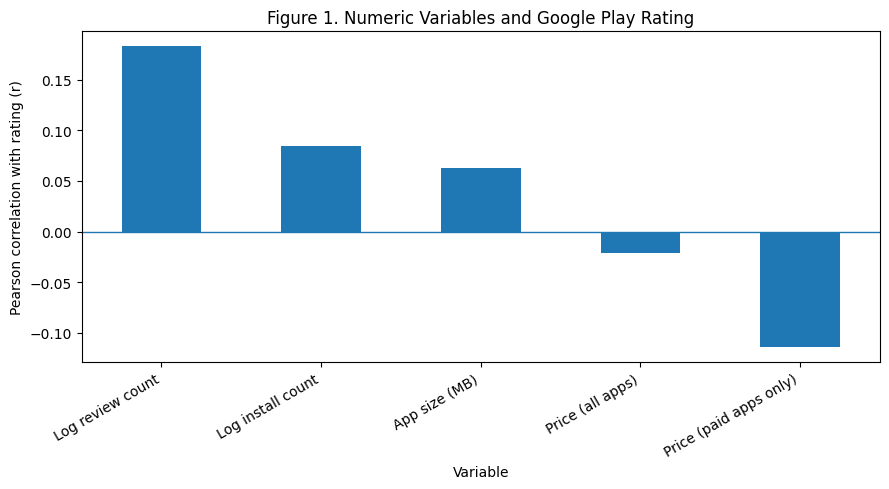

In [ ]:
plt.figure(figsize=(9, 5))
correlations.plot(kind="bar")
plt.axhline(0, linewidth=1)
plt.ylabel("Pearson correlation with rating (r)")
plt.xlabel("Variable")
plt.title("Figure 1. Numeric Variables and Google Play Rating")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Average rating by install range

In [ ]:
install_bins = [
    -np.inf,
    10_000,
    100_000,
    1_000_000,
    10_000_000,
    np.inf,
]

install_labels = [
    "<10,000",
    "10,000-99,999",
    "100,000-999,999",
    "1,000,000-9,999,999",
    ">=10,000,000",
]

rated_apps["Install_range"] = pd.cut(
    rated_apps["Installs_num"],
    bins=install_bins,
    labels=install_labels,
    right=False
)

install_summary = (
    rated_apps
    .groupby("Install_range", observed=False)["Rating_num"]
    .agg(["count", "mean", "std"])
    .rename(
        columns={
            "count": "App count",
            "mean": "Mean rating",
            "std": "Rating SD",
        }
    )
)

install_summary["Standard error"] = (
    install_summary["Rating SD"]
    / np.sqrt(install_summary["App count"])
)

install_summary["95% CI"] = (
    1.96 * install_summary["Standard error"]
)

install_summary.round(3)

,App count,Mean rating,Rating SD,Standard error,95% CI
Install_range,,,,,
"<10,000",1759,4.156,0.797,0.019,0.037
"10,000-99,999",1443,4.038,0.580,0.015,0.030
"100,000-999,999",1598,4.132,0.467,0.012,0.023
"1,000,000-9,999,999",2022,4.220,0.350,0.008,0.015
">=10,000,000",1374,4.316,0.267,0.007,0.014


### Figure 2. Average rating by install range

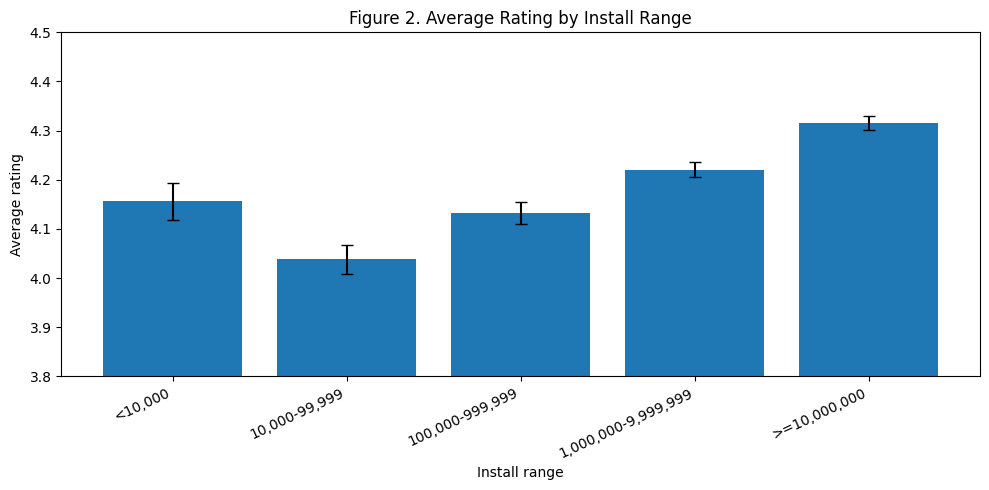

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    install_summary.index.astype(str),
    install_summary["Mean rating"],
    yerr=install_summary["95% CI"],
    capsize=4
)
plt.ylabel("Average rating")
plt.xlabel("Install range")
plt.title("Figure 2. Average Rating by Install Range")
plt.ylim(3.8, 4.5)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 8. Free and paid app comparison

In [ ]:
price_type_summary = (
    rated_apps
    .assign(
        Price_model=np.where(
            rated_apps["Price_usd"] > 0,
            "Paid",
            "Free"
        )
    )
    .groupby("Price_model")["Rating_num"]
    .agg(["count", "mean", "median", "std"])
    .rename(
        columns={
            "count": "App count",
            "mean": "Mean rating",
            "median": "Median rating",
            "std": "Rating SD",
        }
    )
)

price_type_summary.round(3)

,App count,Mean rating,Median rating,Rating SD
Price_model,,,,
Free,7594,4.166,4.3,0.534
Paid,602,4.262,4.4,0.557


In [ ]:
free_mean = price_type_summary.loc["Free", "Mean rating"]
paid_mean = price_type_summary.loc["Paid", "Mean rating"]

print(f"Free apps mean rating: {free_mean:.2f}")
print(f"Paid apps mean rating: {paid_mean:.2f}")
print(f"Difference: {paid_mean - free_mean:.2f} stars")
print(
    "Price correlation among paid apps: "
    f"{correlations['Price (paid apps only)']:.3f}"
)

Free apps mean rating: 4.17
Paid apps mean rating: 4.26
Difference: 0.10 stars
Price correlation among paid apps: -0.114


## 9. Average rating by app category

In [ ]:
category_summary = (
    rated_apps
    .groupby("Category")["Rating_num"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "App count",
            "mean": "Mean rating",
        }
    )
)

# Keep categories with at least 100 rated apps.
large_categories = category_summary[
    category_summary["App count"] >= 100
].sort_values("Mean rating", ascending=False)

large_categories.round(3)

,App count,Mean rating
Category,,
EDUCATION,106,4.355
BOOKS_AND_REFERENCE,169,4.345
PERSONALIZATION,298,4.332
SOCIAL,203,4.247
GAME,899,4.245
HEALTH_AND_FITNESS,244,4.243
SHOPPING,180,4.231
SPORTS,260,4.216
FAMILY,1649,4.183


### Figure 3. Average ratings for categories with at least 100 apps

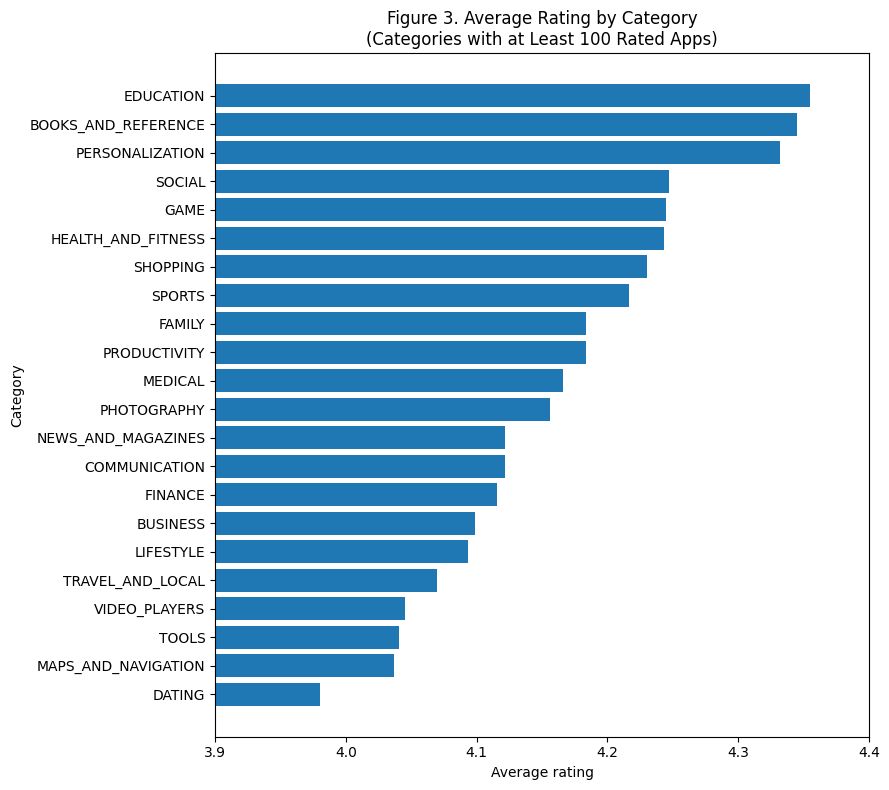

In [ ]:
category_plot = large_categories.sort_values(
    "Mean rating",
    ascending=True
)

plt.figure(figsize=(9, 8))
plt.barh(
    category_plot.index,
    category_plot["Mean rating"]
)
plt.xlabel("Average rating")
plt.ylabel("Category")
plt.title(
    "Figure 3. Average Rating by Category\n"
    "(Categories with at Least 100 Rated Apps)"
)
plt.xlim(3.9, 4.4)
plt.tight_layout()
plt.show()

## 10. Average rating by content rating

In [ ]:
content_rating_summary = (
    rated_apps
    .groupby("Content Rating")["Rating_num"]
    .agg(["count", "mean", "median"])
    .rename(
        columns={
            "count": "App count",
            "mean": "Mean rating",
            "median": "Median rating",
        }
    )
    .sort_values("Mean rating", ascending=False)
)

content_rating_summary.round(3)

,App count,Mean rating,Median rating
Content Rating,,,
Adults only 18+,3,4.300,4.5
Everyone 10+,305,4.226,4.3
Teen,912,4.226,4.3
Everyone,6618,4.166,4.3
Mature 17+,357,4.122,4.2
Unrated,1,4.100,4.1


## 11. Main findings

In [ ]:
print("MAIN RESULTS")
print("-" * 50)
print(f"Unique rated apps analyzed: {len(rated_apps):,}")
print(f"Average rating: {rated_apps['Rating_num'].mean():.2f}")
print(
    "Review count correlation: "
    f"{correlations['Log review count']:.3f}"
)
print(
    "Install count correlation: "
    f"{correlations['Log install count']:.3f}"
)
print(
    "App size correlation: "
    f"{correlations['App size (MB)']:.3f}"
)
print(
    "Price correlation among paid apps: "
    f"{correlations['Price (paid apps only)']:.3f}"
)
print(
    f"Free app average: {free_mean:.2f}; "
    f"paid app average: {paid_mean:.2f}"
)
print()
print(
    "Conclusion: Review count had the strongest relationship "
    "with rating, but all measured relationships were weak."
)

MAIN RESULTS
--------------------------------------------------
Unique rated apps analyzed: 8,196
Average rating: 4.17
Review count correlation: 0.183
Install count correlation: 0.085
App size correlation: 0.063
Price correlation among paid apps: -0.114
Free app average: 4.17; paid app average: 4.26

Conclusion: Review count had the strongest relationship with rating, but all measured relationships were weak.


## 12. Optional: save the cleaned dataset

This cell saves the 8,196 unique rated apps used in the analysis.

In [ ]:
output_columns = [
    "App",
    "Category",
    "Rating_num",
    "Reviews_num",
    "Installs_num",
    "Size_mb",
    "Type",
    "Price_usd",
    "Content Rating",
]

output_name = "googleplay_cleaned_unique_rated_notebook.csv"
output_folder = Path("/mnt/data") if Path("/mnt/data").exists() else Path.cwd()
cleaned_output_path = output_folder / output_name

rated_apps[output_columns].to_csv(
    cleaned_output_path,
    index=False
)

print(f"Saved: {cleaned_output_path}")

Saved: /mnt/data/googleplay_cleaned_unique_rated_notebook.csv
